<a href="https://colab.research.google.com/github/syiffac/TikTok-Trends-Classification_ML/blob/main/ML_Tiktok_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# load dataset
df = pd.read_csv('youtube_shorts_tiktok_trends_2025.csv')

# lihat 5 data awal
df.head()

# info dataset
df.info()

# statistik dasar
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 48079 non-null  object 
 1   country                  48079 non-null  object 
 2   region                   48079 non-null  object 
 3   language                 48079 non-null  object 
 4   category                 48079 non-null  object 
 5   hashtag                  48079 non-null  object 
 6   title_keywords           48079 non-null  object 
 7   author_handle            48079 non-null  object 
 8   sound_type               48079 non-null  object 
 9   music_track              48079 non-null  object 
 10  week_of_year             48079 non-null  int64  
 11  duration_sec             48079 non-null  int64  
 12  views                    48079 non-null  int64  
 13  likes                    48079 non-null  int64  
 14  comments              

,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,upload_hour,trend_duration_days,...,avg_watch_time_sec,completion_rate,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
count,48079.000000,48079.000000,4.807900e+04,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,...,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000
mean,18.234260,34.489320,9.929276e+04,5737.732108,628.657314,553.484494,591.071487,0.075415,15.986751,13.742923,...,21.662460,0.635308,0.622995,7510.945402,0.057607,0.002462,75.415322,0.057607,0.006310,0.005556
std,9.996924,16.401608,1.318522e+05,8639.923653,967.782704,849.436172,978.280616,0.030091,5.489399,13.343582,...,10.583019,0.112604,0.484641,11262.284575,0.023123,0.001586,30.090519,0.023123,0.002969,0.002496
min,1.000000,5.000000,7.940000e+02,33.000000,3.000000,3.000000,2.000000,0.014720,0.000000,3.000000,...,2.800000,0.400000,0.000000,43.000000,0.011792,0.000000,14.720000,0.011792,0.000975,0.000735
25%,10.000000,22.000000,3.032250e+04,1526.000000,160.000000,143.000000,138.000000,0.052326,13.000000,5.000000,...,14.000000,0.548000,0.000000,1998.000000,0.039941,0.001273,52.326000,0.039941,0.004058,0.003670
50%,18.000000,31.000000,5.962000e+04,3167.000000,339.000000,301.000000,301.000000,0.071575,17.000000,7.000000,...,19.400000,0.635000,1.000000,4159.000000,0.054654,0.002138,71.575000,0.054654,0.005809,0.005163
75%,27.000000,43.000000,1.180945e+05,6618.000000,720.000000,635.000000,659.500000,0.094794,20.000000,17.000000,...,27.000000,0.724000,1.000000,8675.000000,0.072280,0.003276,94.793500,0.072281,0.008016,0.007000
max,35.000000,90.000000,3.080686e+06,310916.000000,31776.000000,29004.000000,29679.000000,0.235819,23.000000,60.000000,...,67.300000,0.850000,1.000000,390142.000000,0.185300,0.012718,235.819000,0.185300,0.023668,0.020328


In [ ]:
# lihat median views
df['views'].median()
df['viral'] = df['views'].apply(lambda x: 1 if x > df['views'].median() else 0)
df['viral'].value_counts()

,count
viral,
0,24040
1,24039


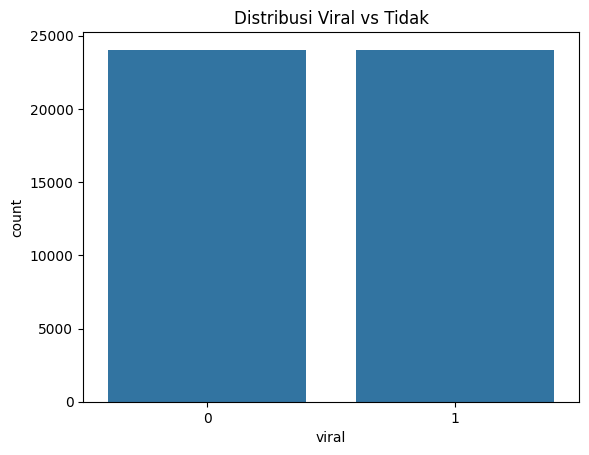

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='viral', data=df)
plt.title('Distribusi Viral vs Tidak')
plt.show()

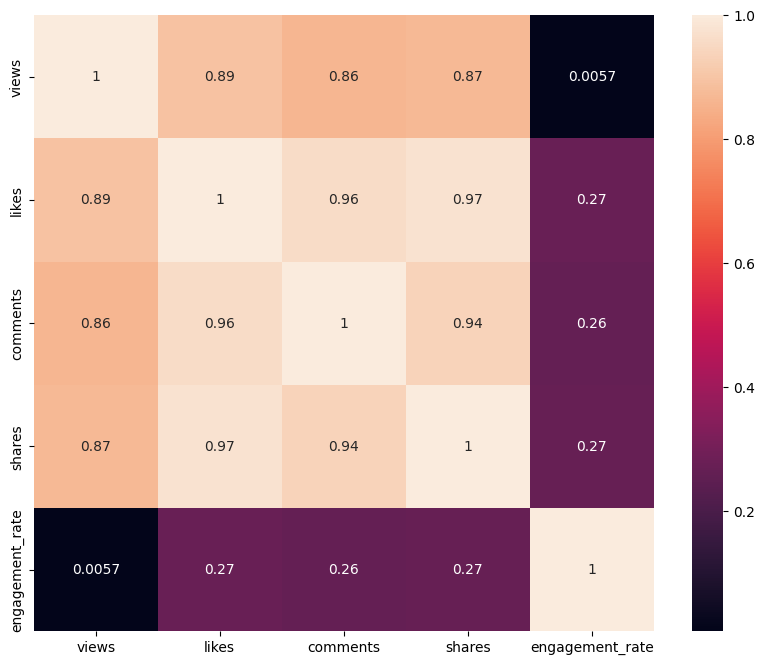

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['views','likes','comments','shares','engagement_rate']].corr(), annot=True)
plt.show()

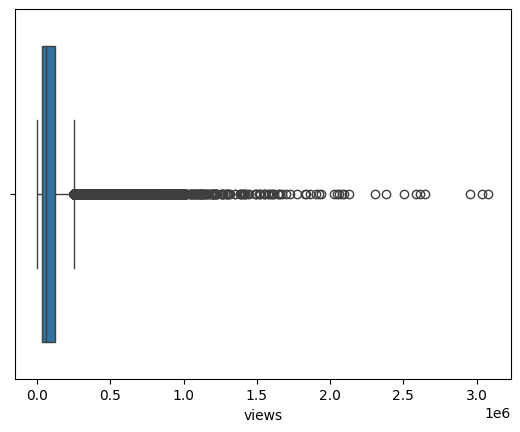

In [ ]:
sns.boxplot(x=df['views'])
plt.show()

In [ ]:
drop_cols = [
    'views',  # karena dipakai bikin target
    'engagement_total',
    'like_rate',
    'dislike_rate',
    'share_rate',
    'save_rate',
    'engagement_rate',
    'engagement_per_1k',
    'engagement_like_rate',
    'engagement_comment_rate',
    'engagement_share_rate',
    'row_id',
    'title',
    'sample_comments',
    'tags'
]

df = df.drop(columns=drop_cols)
print(df.columns.tolist())

['platform', 'country', 'region', 'language', 'category', 'hashtag', 'title_keywords', 'author_handle', 'sound_type', 'music_track', 'week_of_year', 'duration_sec', 'likes', 'comments', 'shares', 'saves', 'trend_label', 'source_hint', 'notes', 'device_type', 'upload_hour', 'genre', 'trend_duration_days', 'trend_type', 'engagement_velocity', 'dislikes', 'comment_ratio', 'like_dislike_ratio', 'publish_dayofweek', 'publish_period', 'event_season', 'creator_avg_views', 'creator_tier', 'season', 'publish_date_approx', 'year_month', 'title_length', 'has_emoji', 'avg_watch_time_sec', 'completion_rate', 'device_brand', 'traffic_source', 'is_weekend', 'viral']


In [ ]:
drop_lagi = [
    'hashtag',
    'title_keywords',
    'author_handle',
    'music_track',
    'source_hint',
    'notes',
    'publish_date_approx',
    'year_month'
]

df = df.drop(columns=drop_lagi, errors='ignore')

In [ ]:
features = [
    'likes',
    'comments',
    'shares',
    'duration_sec',
    'upload_hour',
    'completion_rate',
    'avg_watch_time_sec',
    'category',
    'platform',
    'genre',
    'publish_dayofweek',
    'device_type',
    'traffic_source'
]

X = df[features]
y = df['viral']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy LR:", accuracy_score(y_test, y_pred_lr))
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))

Accuracy LR: 0.9033901830282862
Accuracy RF: 0.9026622296173045


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91      4843
           1       0.92      0.89      0.90      4773

    accuracy                           0.90      9616
   macro avg       0.90      0.90      0.90      9616
weighted avg       0.90      0.90      0.90      9616

Random Forest:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90      4843
           1       0.91      0.90      0.90      4773

    accuracy                           0.90      9616
   macro avg       0.90      0.90      0.90      9616
weighted avg       0.90      0.90      0.90      9616



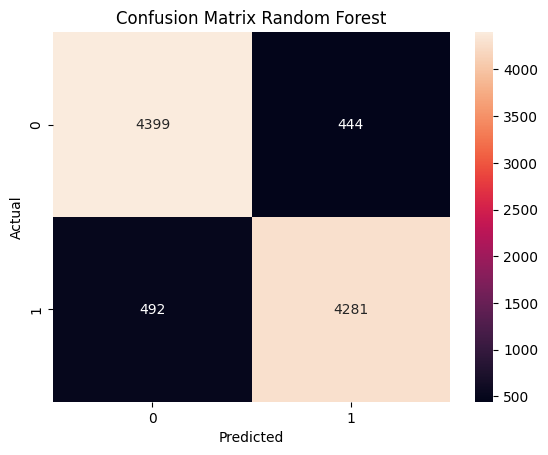

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()